In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import json
import os
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

print(f"numpy:   {np.__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"shap:    {shap.__version__}")

# Load saved model and feature list
model_path   = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\models\xgboost_credit_risk_v2.pkl"
feature_path = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\models\feature_list.pkl"

model        = joblib.load(model_path)
feature_list = joblib.load(feature_path)

# Load cleaned data
data_path = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\outputs\loans_cleaned.parquet"
df = pd.read_parquet(data_path)

# Recreate X and y — identical to modelling notebook
X = df.drop(columns=['target', 'grade', 'int_rate'])
y = df['target']

# Identical split — same random_state guarantees same rows as before
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nModel loaded:  {type(model).__name__}")
print(f"Features:      {len(feature_list)}")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nReady for SHAP")

numpy:   1.26.4
xgboost: 2.1.1
shap:    0.47.2

Model loaded:  XGBClassifier
Features:      76
Test set:      268,889 rows

Ready for SHAP


In [7]:
print("Creating SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)
print(f"Explainer created successfully!")
print(f"Base rate (avg predicted probability): {explainer.expected_value[0]:.4f}")

Creating SHAP TreeExplainer...
Explainer created successfully!
Base rate (avg predicted probability): 0.0000


In [10]:
print("Preparing sample of 5,000 test applicants...")

# Sample 5,000 rows from test set
# 5,000 is standard for SHAP — large enough to be representative
# small enough to compute in minutes rather than hours
X_sample = X_test.sample(n=5000, random_state=42).copy()
y_sample  = y_test.loc[X_sample.index].copy()

# Convert boolean columns to integers
# SHAP requires fully numeric input
bool_cols = X_sample.select_dtypes(include='bool').columns
X_sample[bool_cols] = X_sample[bool_cols].astype(int)

print(f"Sample shape: {X_sample.shape}")
print(f"Defaults in sample: {y_sample.sum():,} ({y_sample.mean()*100:.1f}%)")

print("\nComputing SHAP values...")
print("This takes 3-5 minutes — each of 5,000 applicants")
print("gets an explanation across all 76 features\n")

shap_values = explainer.shap_values(X_sample)

print(f"Done!")
print(f"SHAP matrix shape: {shap_values.shape}")
print(f"  → {shap_values.shape[0]:,} applicants")
print(f"  → {shap_values.shape[1]} features")
print(f"\nEach cell = how much that feature pushed")
print(f"that applicant's score away from the base rate")

Preparing sample of 5,000 test applicants...
Sample shape: (5000, 76)
Defaults in sample: 1,011 (20.2%)

Computing SHAP values...
This takes 3-5 minutes — each of 5,000 applicants
gets an explanation across all 76 features

Done!
SHAP matrix shape: (5000, 76)
  → 5,000 applicants
  → 76 features

Each cell = how much that feature pushed
that applicant's score away from the base rate


Generating global summary plot...


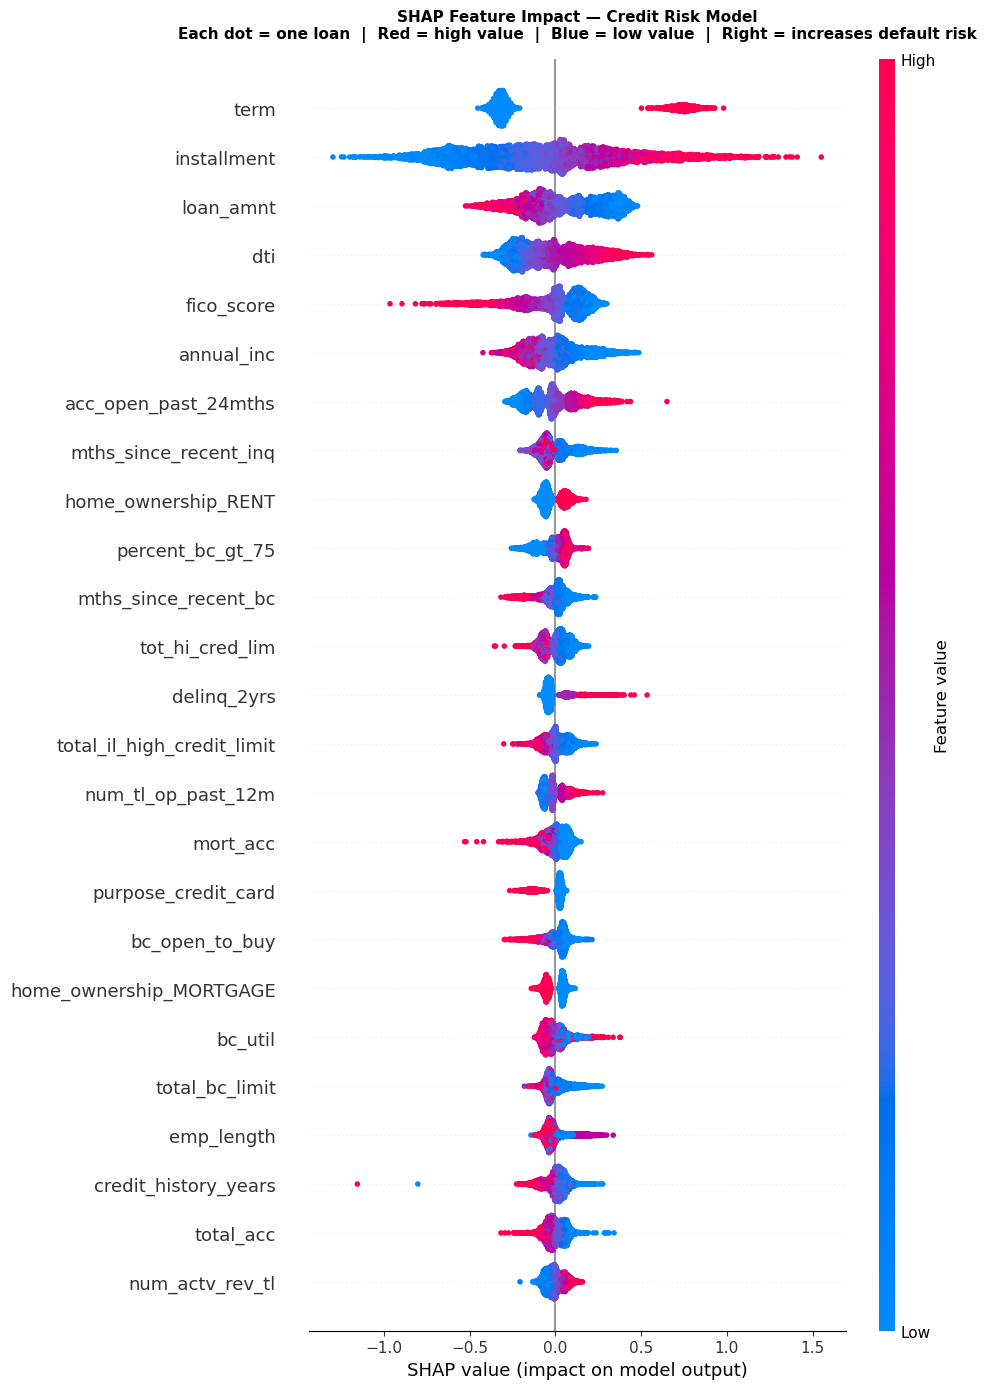

Saved: shap_summary.png


In [12]:
# This is the most important SHAP visualisation
# Shows all 76 features ranked by overall impact
# Each dot is one loan application

print("Generating global summary plot...")

plt.figure(figsize=(10, 14))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_list,
    max_display=25,
    show=False,
    plot_size=(10, 14)
)

plt.title(
    'SHAP Feature Impact — Credit Risk Model\n'
    'Each dot = one loan  |  '
    'Red = high value  |  '
    'Blue = low value  |  '
    'Right = increases default risk',
    fontsize=11,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plot_path = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\outputs\shap_summary.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

In [14]:
# Get predicted probabilities for all 5,000 sampled applicants
probas = model.predict_proba(X_sample)[:, 1]

print("Risk distribution in sample:")
print(f"  Very Low Risk  (< 10%):   {(probas < 0.10).sum():,}")
print(f"  Low Risk   (10–25%):      {((probas >= 0.10) & (probas < 0.25)).sum():,}")
print(f"  Medium Risk (25–50%):     {((probas >= 0.25) & (probas < 0.50)).sum():,}")
print(f"  High Risk   (50–70%):     {((probas >= 0.50) & (probas < 0.70)).sum():,}")
print(f"  Very High Risk (> 70%):   {(probas > 0.70).sum():,}")

# Select one high risk and one low risk applicant
high_risk_positions = np.where(probas > 0.65)[0]
low_risk_positions  = np.where(probas < 0.08)[0]

high_idx = high_risk_positions[0]
low_idx  = low_risk_positions[0]

print(f"\nHigh risk applicant selected:")
print(f"  Predicted probability: {probas[high_idx]:.1%}")
print(f"  Actual outcome: {'DEFAULT' if y_sample.iloc[high_idx] == 1 else 'FULLY PAID'}")

print(f"\nLow risk applicant selected:")
print(f"  Predicted probability: {probas[low_idx]:.1%}")
print(f"  Actual outcome: {'DEFAULT' if y_sample.iloc[low_idx] == 1 else 'FULLY PAID'}")

Risk distribution in sample:
  Very Low Risk  (< 10%):   114
  Low Risk   (10–25%):      763
  Medium Risk (25–50%):     2,109
  High Risk   (50–70%):     1,444
  Very High Risk (> 70%):   570

High risk applicant selected:
  Predicted probability: 70.7%
  Actual outcome: FULLY PAID

Low risk applicant selected:
  Predicted probability: 7.6%
  Actual outcome: FULLY PAID


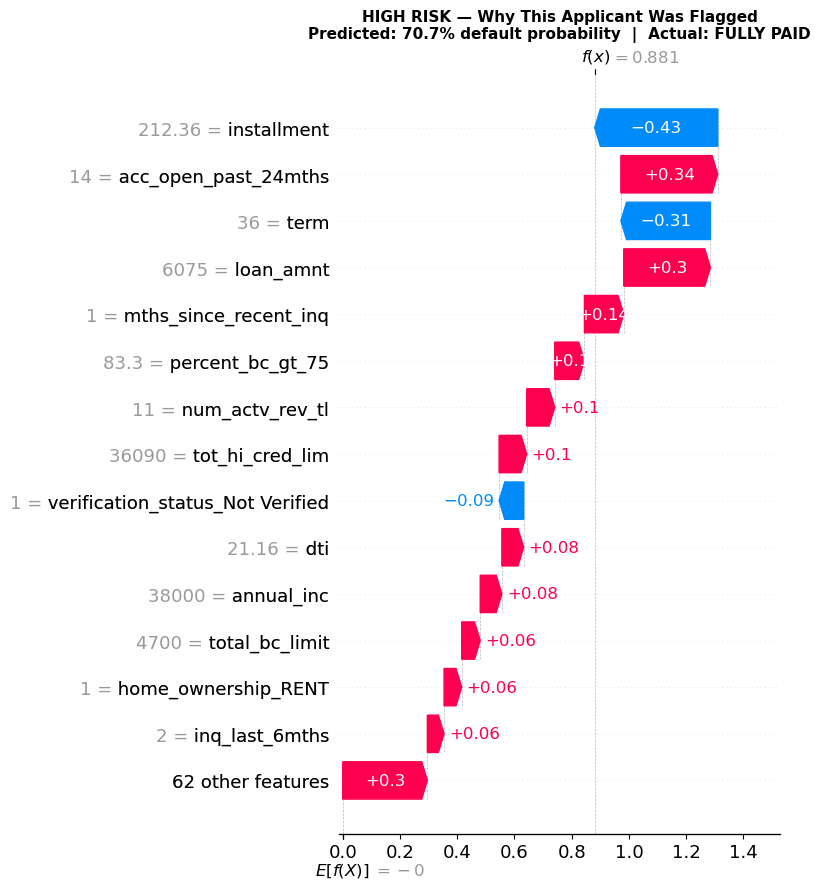

Saved: shap_waterfall_highrisk.png


In [16]:
# Waterfall plot shows exactly how we arrived at
# this specific applicant's score — starting from
# the base rate and adding/subtracting each feature's contribution

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[high_idx].values,
        feature_names=feature_list
    ),
    max_display=15,
    show=False
)

plt.title(
    f'HIGH RISK — Why This Applicant Was Flagged\n'
    f'Predicted: {probas[high_idx]:.1%} default probability  |  '
    f'Actual: {"DEFAULT ✓" if y_sample.iloc[high_idx] == 1 else "FULLY PAID"}',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

plot_path = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\outputs\shap_waterfall_highrisk.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_highrisk.png")

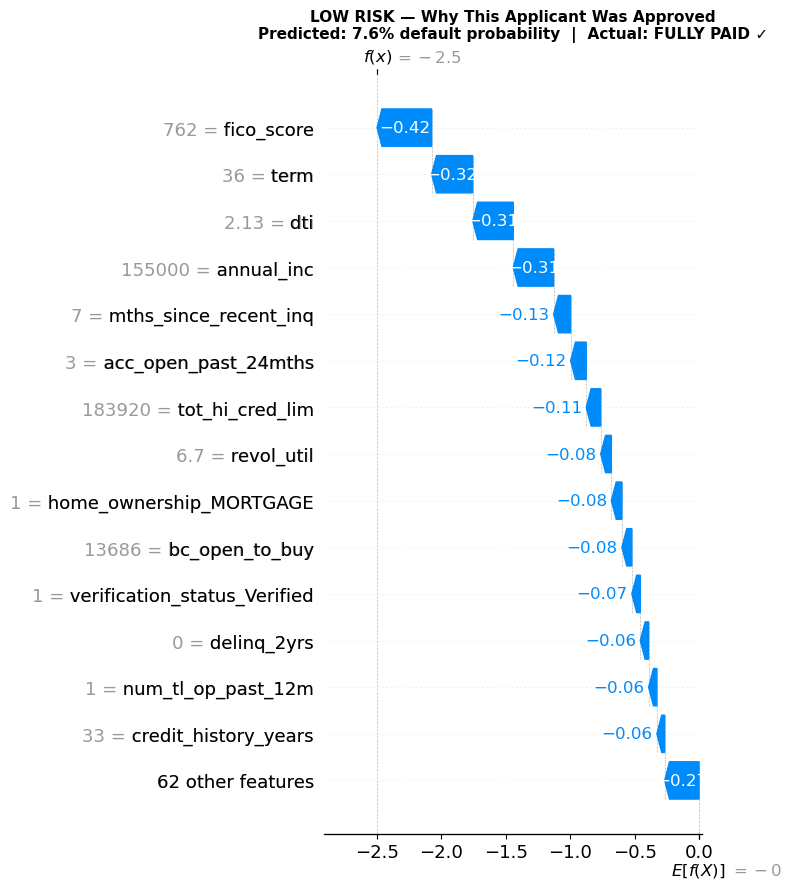

Saved: shap_waterfall_lowrisk.png


In [18]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[low_idx].values,
        feature_names=feature_list
    ),
    max_display=15,
    show=False
)

plt.title(
    f'LOW RISK — Why This Applicant Was Approved\n'
    f'Predicted: {probas[low_idx]:.1%} default probability  |  '
    f'Actual: {"DEFAULT" if y_sample.iloc[low_idx] == 1 else "FULLY PAID ✓"}',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

plot_path = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\outputs\shap_waterfall_lowrisk.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_lowrisk.png")

In [20]:
# Print key features for both applicants side by side
# This is the human story behind the waterfall plots

key_features = [
    'term', 'fico_score', 'dti', 'annual_inc',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc',
    'credit_history_years', 'revol_util', 'emp_length'
]

print("=" * 62)
print("  APPLICANT COMPARISON — KEY FEATURES")
print("=" * 62)
print(f"  {'Feature':<30} {'High Risk':>12} {'Low Risk':>12}")
print("-" * 62)

for feat in key_features:
    if feat in X_sample.columns:
        high_val = X_sample.iloc[high_idx][feat]
        low_val  = X_sample.iloc[low_idx][feat]
        print(f"  {feat:<30} {high_val:>12.1f} {low_val:>12.1f}")

print("-" * 62)
print(f"  {'Predicted Default Prob':<30} "
      f"{probas[high_idx]:>11.1%} "
      f"{probas[low_idx]:>11.1%}")
print(f"  {'Actual Outcome':<30} "
      f"{'DEFAULT':>12} "
      f"{'FULLY PAID':>12}")
print("=" * 62)

  APPLICANT COMPARISON — KEY FEATURES
  Feature                           High Risk     Low Risk
--------------------------------------------------------------
  term                                   36.0         36.0
  fico_score                            692.0        762.0
  dti                                    21.2          2.1
  annual_inc                          38000.0     155000.0
  delinq_2yrs                             0.0          0.0
  inq_last_6mths                          2.0          0.0
  mort_acc                                0.0          2.0
  credit_history_years                   17.0         33.0
  revol_util                             36.0          6.7
  emp_length                              2.0         10.0
--------------------------------------------------------------
  Predicted Default Prob               70.7%        7.6%
  Actual Outcome                      DEFAULT   FULLY PAID


In [22]:
# Save SHAP values for potential use in the API later
outputs_dir = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\outputs"

np.save(os.path.join(outputs_dir, 'shap_values_sample.npy'), shap_values)
X_sample.to_parquet(os.path.join(outputs_dir, 'X_sample.parquet'))

print("Phase 3 Complete!")
print("=" * 45)
print("\nFiles saved:")
for f in sorted(os.listdir(outputs_dir)):
    size = os.path.getsize(os.path.join(outputs_dir, f))
    print(f"  {f:<45} {size/1024:>6.0f} KB")

Phase 3 Complete!

Files saved:
  X_sample.parquet                                 518 KB
  feature_importance.png                           133 KB
  feature_importance_v2.png                        141 KB
  loans_cleaned.parquet                          87253 KB
  shap_summary.png                                 324 KB
  shap_values_sample.npy                          1484 KB
  shap_waterfall_highrisk.png                      149 KB
  shap_waterfall_lowrisk.png                       154 KB
